### Simulation Investigation into Conditional Trend Filtering and Changepoint Detection on High-Frequency Price Process

Jason Bohne

Jason.bohne@stonybrook.edu

Applied Math and Stats Ph.D. Student 

Under Supervision of Professor Pawel Polak


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')

from kernel_smoother import smooth_series, cv_block_size, mom_kde
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### Prep Data

- First minute seconds of trade data for AAPL after open across availble U.S. equity exchanges
- Group observations by participant side timestamp; averaging price and summing volume
- Results in ~1400 observations
- Preprocessed and cleaned to remove trades executed before open

In [80]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0).dropna()
trades=trades[trades.index < "2020-01-02 09:31:00"]
trades=trades[trades.index> "2020-01-02 09:30:00"]
trades.index=pd.to_datetime(trades.index)
trades['Index']=trades.index
trades=trades.groupby('Index').agg({'Trade_Price':np.mean, 'Trade_Volume':np.sum})


trades['Trade_Price']=np.log(trades['Trade_Price'])
trades=trades[trades['Trade_Volume']<1000]


trades

,Trade_Price,Trade_Volume
Index,,
2020-01-02 09:30:00.134336,5.691170,250
2020-01-02 09:30:00.134371,5.691170,50
2020-01-02 09:30:00.134532,5.691069,108
2020-01-02 09:30:00.157191,5.691305,2
2020-01-02 09:30:00.193558,5.691136,5
...,...,...
2020-01-02 09:30:59.613591,5.689481,5
2020-01-02 09:30:59.613627,5.689469,230
2020-01-02 09:30:59.613659,5.689481,40


### Step 1; Generate Prior

- In our analysis trade volume will be used as a prior for changes in underlying price trend however any discrete series can be utilized (realized volatility)
- Normalize time of prior to be incremented in total seconds

In [81]:
original_index=trades['Trade_Volume'].index
volume_index=[(i -original_index[0]).total_seconds() for i in original_index]
volume_prior=trades['Trade_Volume'].values

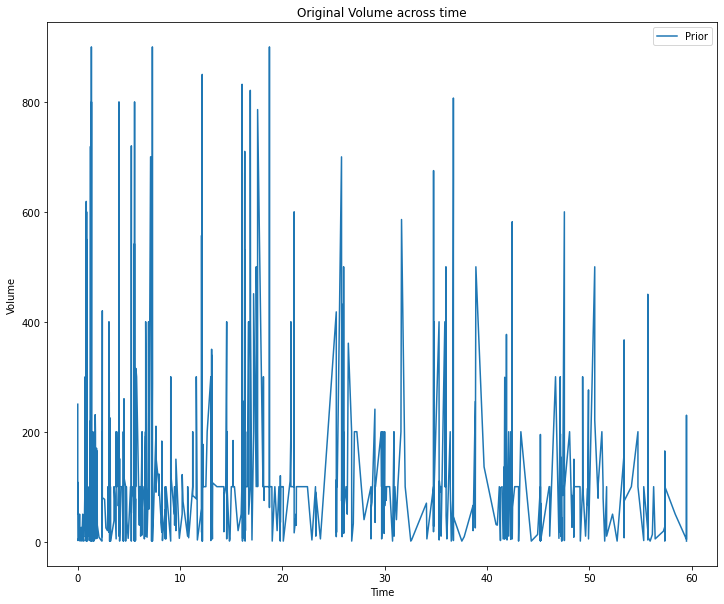

In [82]:
fig,ax=plt.subplots(figsize=(12,10))
plt.title("Original Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
plt.plot(volume_index,volume_prior,label="Prior")
plt.legend()

### Step 2; Smooth Prior

- Original prior is discrete and experiences high frequency of jumps
- Apply smoothing for better interpretability

Kernel Density Smoothing
- Nonparametric smoothing method which smooths candidate point $ x_i$ as a weighted average of all observations $x_j$ where weights $w_i$ are a function of their distance in time from candidate point
- Gaussian Kernels specify function of a normal density
- Optimal bandwidth is selected either through Scott's or Silvermans.


In [83]:
kde_smooth,optimal_bw=smooth_series(volume_prior,volume_index)

### Step 3; Add Robustness to Estimator

- Outliers can significantly skew smoothing estimator
- Apply Median of Means which partitions observations into N blocks
- For each block apply kernel density estimation to generate kernel $k_i$; estimating candidate point as the median of the $k_j \forall j$
- Cross validate hyperparameter N; specifying number of block partitions

In [84]:
block_params=np.arange(1,100,10)
optimal_mom_kde_bw,optimal_mse=cv_block_size(volume_prior,kde_smooth,volume_prior,optimal_bw,block_params,True)

 MSE for 1 blocks is 24838808.36
 MSE for 11 blocks is 25222352.25
 MSE for 21 blocks is 25254313.25
 MSE for 31 blocks is 25258143.59
 MSE for 41 blocks is 25259506.4
 MSE for 51 blocks is 25261407.14
 MSE for 61 blocks is 25261849.4
 MSE for 71 blocks is 25267855.22
 MSE for 81 blocks is 25270696.1
 MSE for 91 blocks is 25270394.88


In [85]:
optimal_mom_kde=mom_kde(kde_smooth,volume_index,optimal_mom_kde_bw,optimal_bw)

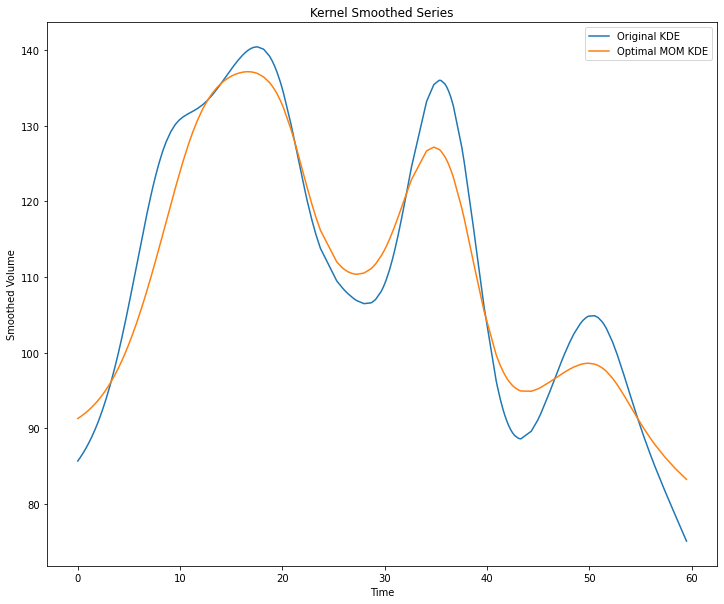

In [86]:
fig,ax=plt.subplots(figsize=(12,10))

plt.title("Kernel Smoothed Series")
plt.ylabel("Smoothed Volume")
plt.xlabel("Time")
plt.plot(volume_index,kde_smooth,label="Original KDE")
plt.plot(volume_index,optimal_mom_kde,label="Optimal MOM KDE")
plt.legend()

### Step 4; Sample Variance process
- As we believe the prior is responsible for changes in the underlying trend; we simulate the variance process of the underlying trend using the prior series
- Larger prior values (trade volume) correspond to larger variance in underlying trend
- Smaller prior values (trade volume) correspond to smaller variance in underlying trend


In [87]:
def sample_from_prior(smooth_prior):
    """ Sample variance process given smoothed prior
    """
    samples=[]
    for x_i in smooth_prior:
        scale=2/(x_i**2)
        s_i=(x_i/2)*np.random.exponential(scale=scale)
        
        samples.append(s_i)
    
    return samples

In [88]:
variance_estimates=sample_from_prior(optimal_mom_kde)

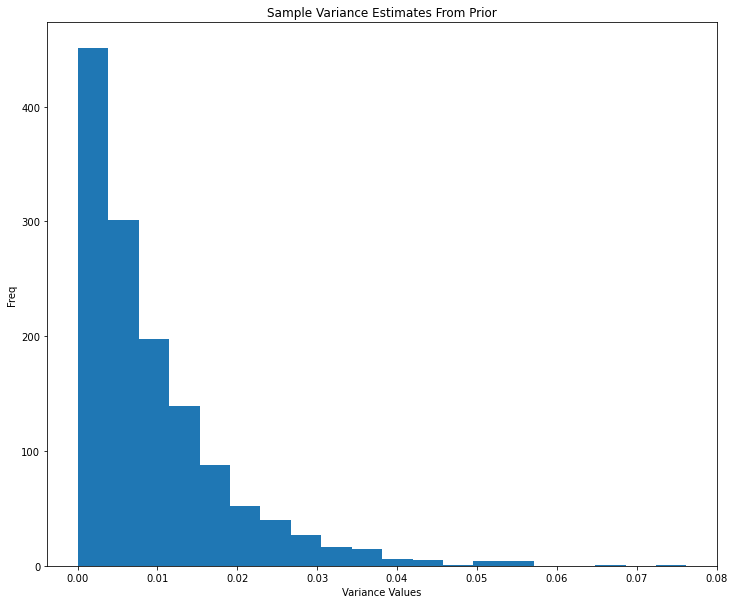

In [89]:
fig,ax=plt.subplots(figsize=(12,10))
plt.title("Sample Variance Estimates From Prior")
plt.xlabel("Variance Values")
plt.ylabel("Freq")
bins=plt.hist(variance_estimates,bins=20)

### Step 5 ; Simulate underlying trend given variance estimates 

- Given variance estimates we can simulate price series across time
- Each value $X_t$ follows a normal distribution of mean $2X_{t-1}-XX_{t-2}$ with variance dictated by estimates above
- Interpretation is that most consecutive values will be piecewise linear with small noise; with sparse jumps arising from larger variance 


In [90]:
def sample_price_series(variance_estimates,variance=1,init=0):
    """ Sample price series by given sparse series representing discrete variance process across time
    """
    
    obs=[]
    obs.append(0)
    obs.append(0)
    for count,param in enumerate(variance_estimates):
        mu=2*obs[count-1]-obs[count-2]

        scale=np.sqrt(param)*variance

        sample=np.random.normal(loc=mu,scale=scale,size=1)[0]
        
        obs.append(-1*(sample-mu) )
    
    obs=np.cumsum(np.array(obs))+init

    return obs[1:-1]

In [95]:
price_series=sample_price_series(variance_estimates,variance=0.05,init=50)

Text(0.5, 1.0, 'Simulated Path')

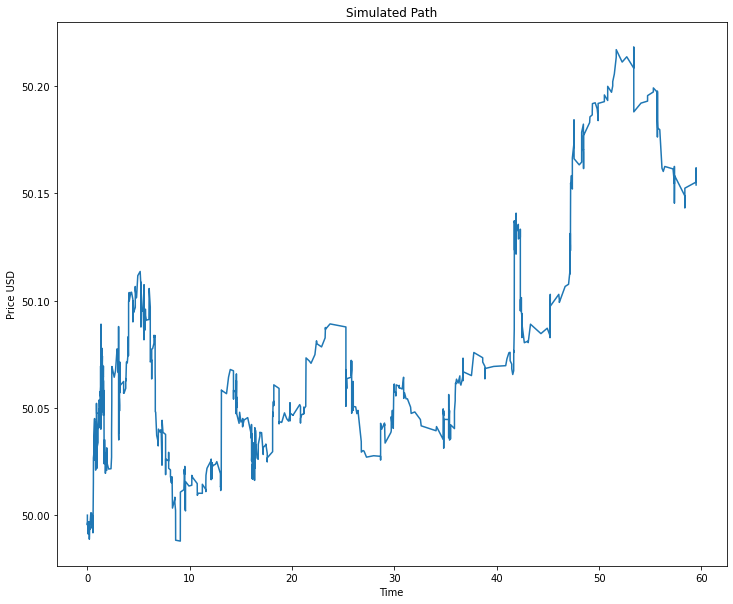

In [96]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,price_series)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

### Numerical Result 1; L1 trend filtering accounting for irregularly spaced observations

- Given the simulated path from step 5; we wish to apply L1 trend filtering to the problem
- Incorporates irregular spacing between observations
- Constrains our estimator to be piecewise linear 
- Here the penalty is set to a constant; dictated by our sensitivity to number of changepoints
    - Hyperparameter can be cross validated

In [117]:
trend_filter_series,status,D=l1tf_adaptive_ir(price_series.reshape(-1,1),t=volume_index,lambda_p=250)

pobj1: [[3.92317558e+10]], pobj2: [[94804496.25124884]], dobj: [[0.]], gap: [[94804496.25124884]]
pobj1: [[3.55673523e+12]], pobj2: [[4.41279309]], dobj: [[0.37399966]], gap: [[4.03879343]]
pobj1: [[3.65117239e+09]], pobj2: [[0.77176441]], dobj: [[0.72665828]], gap: [[0.04510613]]
solved
pobj1: [[6.69556643e+08]], pobj2: [[0.73787873]], dobj: [[0.72885384]], gap: [[0.00902489]]


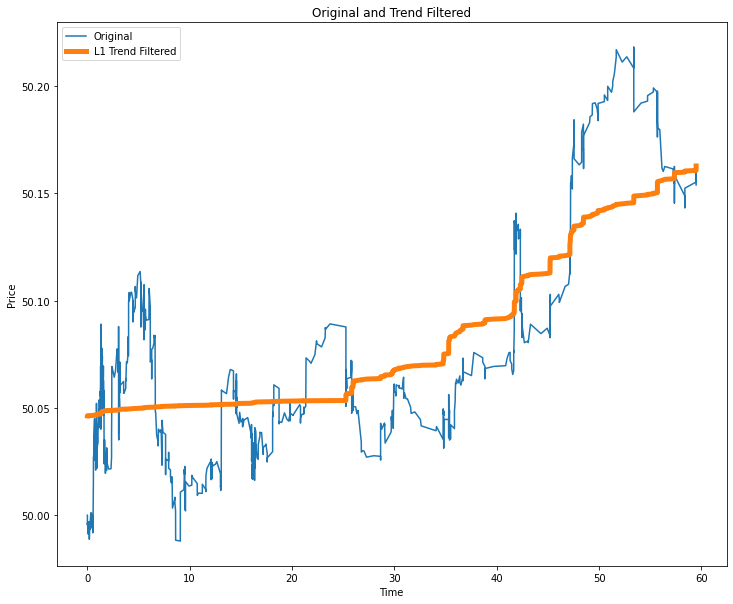

In [118]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,price_series,label='Original')
plt.plot(volume_index,trend_filter_series,label='L1 Trend Filtered',lw=5)
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Numerical Result 1; Adaptive L1 trend filtering  
- Estimator is piecewise linear accounting for irregular observations
- Sensitivity of estimator to changes in underlying trend is conditional on inverse of prior 
- Included explicitly as adaptive penalty (scaled by scale_factor)

In [115]:
scale_factor=10e1
adaptive_trend_filter_series,status,D=l1tf_adaptive_ir(price_series.reshape(-1,1),t=volume_index,lambda_p=scale_factor*1/optimal_mom_kde[1:-1])

pobj1: [[2.71420413e+09]], pobj2: [[375198.84169884]], dobj: [[0.]], gap: [[375198.84169884]]
pobj1: [[7.01383595e+15]], pobj2: [[0.54719741]], dobj: [[0.08443602]], gap: [[0.46276139]]
pobj1: [[3.24705543e+15]], pobj2: [[0.3048953]], dobj: [[0.12670395]], gap: [[0.17819134]]
pobj1: [[9.89578173e+16]], pobj2: [[0.28825103]], dobj: [[0.14107515]], gap: [[0.14717588]]
pobj1: [[2.06030927e+18]], pobj2: [[0.27223299]], dobj: [[0.14230488]], gap: [[0.12992811]]
pobj1: [[9.49220942e+16]], pobj2: [[0.24605135]], dobj: [[0.1450217]], gap: [[0.10102965]]
pobj1: [[7.08137714e+14]], pobj2: [[0.2302759]], dobj: [[0.14703283]], gap: [[0.08324308]]
pobj1: [[8.00774984e+16]], pobj2: [[0.22107084]], dobj: [[0.15404819]], gap: [[0.06702265]]
pobj1: [[2.24931249e+16]], pobj2: [[0.21468437]], dobj: [[0.15587866]], gap: [[0.05880571]]
pobj1: [[1.49431099e+19]], pobj2: [[0.21390491]], dobj: [[0.15596342]], gap: [[0.0579415]]
pobj1: [[4.42134127e+14]], pobj2: [[0.20530627]], dobj: [[0.15665249]], gap: [[0.0

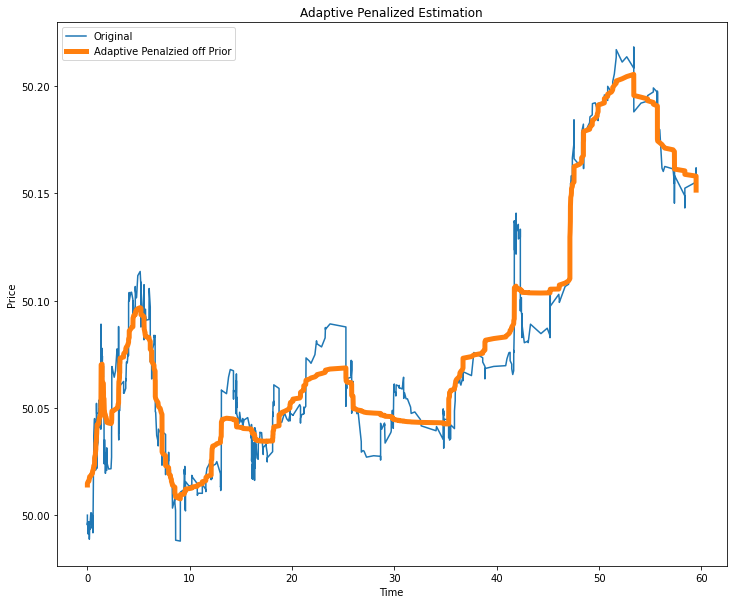

In [116]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,price_series,label='Original')
plt.plot(volume_index,adaptive_trend_filter_series,label='Adaptive Penalzied off Prior',lw=5)
plt.title("Adaptive Penalized Estimation")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Step 7; Changepoint Extraction

- As estimator is piecweise linear; changepoints can be recovered in both simulations with second order difference operator

In [136]:
def extract_cp(smooth,difference_order=2,threshold=1e-6):
    """ Extract changepoints via difference operator 
    """
    diff_mat=Dmat(len(smooth),2).todense()
    diff=np.dot(diff_mat,smooth).reshape(1,-1)[0]
    
    x,y,index=np.where([abs(diff)>threshold])
    return index

In [137]:
changepoints=extract_cp(trend_filter_series)
adaptive_changepoints=extract_cp(adaptive_trend_filter_series,threshold=1e-4)

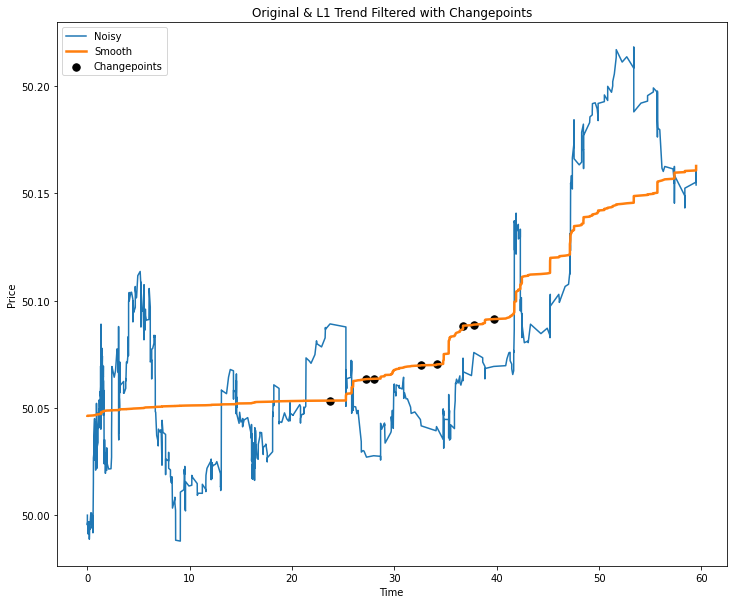

In [138]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,price_series,label='Noisy')
plt.plot(volume_index,trend_filter_series,label='Smooth',lw=2.5)
plt.scatter(np.array(volume_index)[changepoints],trend_filter_series[changepoints],color='black',s=55,label='Changepoints')
plt.title("Original & L1 Trend Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

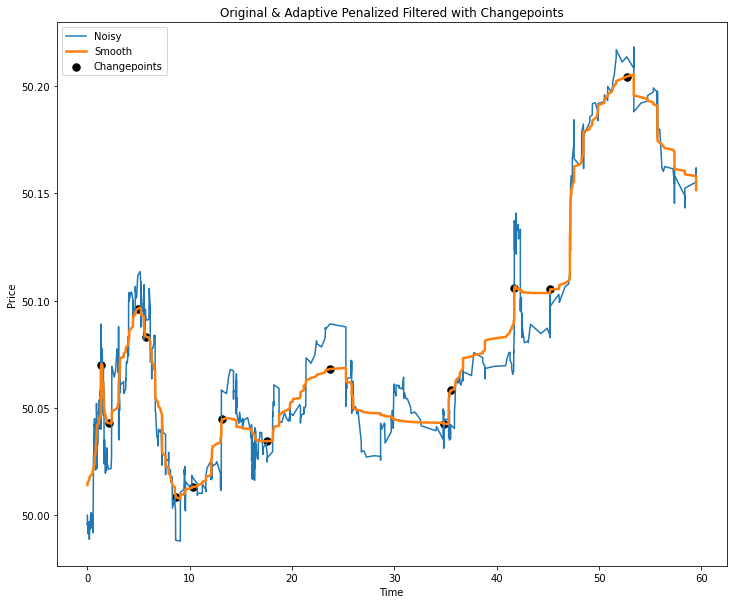

In [ ]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,price_series,label='Noisy')
plt.plot(volume_index,adaptive_trend_filter_series,label='Smooth',lw=2.5)
plt.scatter(np.array(volume_index)[adaptive_changepoints],adaptive_trend_filter_series[adaptive_changepoints],color='black',s=55,label='Changepoints')
plt.title("Original & Adaptive Penalized Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()